# Filter Audit Viz

Loads `output/eval/` data, builds a `{value: color}` map and renders graphs:

| Audit | Metric | Visualization | Description |
| :--- | :--- | :--- | :--- |
| 1 |  PMI | bar graph | pointwise mutual information |
| 1 | RR | Sankey | retention rate |
| 1 | DV | Line series | data volume |
| 1 | LRP | table | log-retention penalty |
| 1 | PR | table | Pearson's *r* |

In [1]:
import json
from pathlib import Path

import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

## Load data

In [2]:
OUTPUT_DIR = Path("../output/eval")
PMI_PATH = OUTPUT_DIR / "pmi"
SANKEY_PATH = OUTPUT_DIR / "retention/sankeys.json"
PLOT_PATH = OUTPUT_DIR / "retention/plot_data"

In [95]:
pmi_data = {
    p.stem: pd.read_csv(p)
    for p in sorted(PMI_PATH.glob("*.csv"))
}

In [96]:
with open(SANKEY_PATH) as f:
    sankeys = json.load(f)

series = {
    p.stem.replace("retention_", ""): pd.read_csv(p, dtype={"value": str})
    for p in sorted(PLOT_PATH.glob("retention_*.csv"))
}

## Color map

In [97]:
PALETTE = px.colors.qualitative.Set2
EXCLUDED_COLOR = "rgba(150,150,150,0.55)"

all_values = set()
for df in series.values():
    all_values |= set(df["value"].unique())
all_values.discard("total")
all_values = sorted(all_values)

COLOR_MAP = {v: PALETTE[i % len(PALETTE)] for i, v in enumerate(all_values)}

print(f"{len(COLOR_MAP)} values colored")
# COLOR_MAP

180 values colored


# Correlation with CMI score

*Operationalized hypothesis*: document CMI score (continuous \[0, 1\]) is positively correlated with document exclusion (binary 0/1).

For document exclusion after the full pipeline, results are **null**. There is close to zero correlation between CMI score and document exclusion in this scenario. This does make sense because several of the deterministic filters are oriented toward document character/sentence length and repetition; LinCE documents are social media posts that are relatively short.

For document exclusion after only the first filter (language identification), the results are **positive**. There is weak to moderate correlation between CMI score and document exclusion in this case.

In [98]:
# Copied directly from eval.correlation console output
cmi_correlation = {
    "cumulative": {
        "corr": 0.0053,
        "p_value": 0.0268
    },
    "lang_id": {
        "corr": 0.3041,
        "p_value": 0.0
    }
}
cmi_df = pd.DataFrame.from_dict(cmi_correlation, orient='index')
cmi_df

,corr,p_value
cumulative,0.0053,0.0268
lang_id,0.3041,0.0000


In [72]:
print(cmi_df)

\begin{tabular}{lrr}
\toprule
 & corr & p_value \\
\midrule
cumulative & 0.005300 & 0.026800 \\
lang_id & 0.304100 & 0.000000 \\
\bottomrule
\end{tabular}



# Pointwise Mutual Information

*Operationalized hypothesis*: PMI(document feature value; document exclusion) will trend with LEU centrality/peripherality (as represented by cluster ID). 

These specific results are **negative**: PMI for cluster IDs and source corpora are close to zero, indicating independence between document exclusion and this representation of dialect typology when computed in isolation. While there are stronger results for document genres, the scale is compressed when normalized. 

The strongest results in fact are for the feature combinations. One of the strongest **positive** associations with document exclusion is for ICE documents in the spoken modality -- this subset is in fact more strongly associated with localized/dialectal features! 

Interestingly, ICE documents trend by cluster and genre, with the most avoidance of exclusion by cluster centrality and written modality.

In [119]:
def render_pmi_bar(stratum_key, color_map=COLOR_MAP, width=600, height=400, font_size=11):
    df = pmi_data[stratum_key]
    fig = px.bar(
        df, 
        x="pmi", 
        y="feature_value", 
        orientation="h", 
        facet_col=[key] * len(df),
        color="feature_value",
        color_discrete_map=color_map,
        title=f"PMI({stratum_key} value; document excluded)"
    )
    fig.update_layout(showlegend=False, height=height, width=width, font=dict(size=font_size))
    # remove the default "facet_variable =" text from the title of each facet graph
    fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))  
    
    # Remove duplicate axis labels
    fig.for_each_yaxis(lambda axis: axis.update(title=None))
    fig.for_each_xaxis(lambda axis: axis.update(title=None))
    x_min = min(-0.1, df.pmi.min() - 0.1)
    x_max = max(0.1, df.pmi.max() + 0.1)
    fig.update_xaxes(range=[x_min, x_max])
    return fig

def render_npmi_bar(stratum_key, color_map=COLOR_MAP, width=600, height=400, font_size=11):
    df = pmi_data[stratum_key]
    fig = px.bar(
        df, 
        x="npmi", 
        y="feature_value", 
        orientation="h", 
        facet_col=[key] * len(df),
        color="feature_value",
        color_discrete_map=color_map,
        title=f"PMI({stratum_key} value; document excluded)"
    )
    fig.update_layout(showlegend=False, height=height, width=width, font=dict(size=font_size))
    # remove the default "facet_variable =" text from the title of each facet graph
    fig.for_each_annotation(lambda a: a.update(text=a.text.split("=")[-1]))  
    
    # Remove duplicate axis labels
    fig.for_each_yaxis(lambda axis: axis.update(title=None))
    fig.for_each_xaxis(lambda axis: axis.update(title=None))
    x_min = min(-0.1, df.npmi.min() - 0.1)
    x_max = max(0.1, df.npmi.max() + 0.1)
    fig.update_xaxes(range=[x_min, x_max])
    return fig

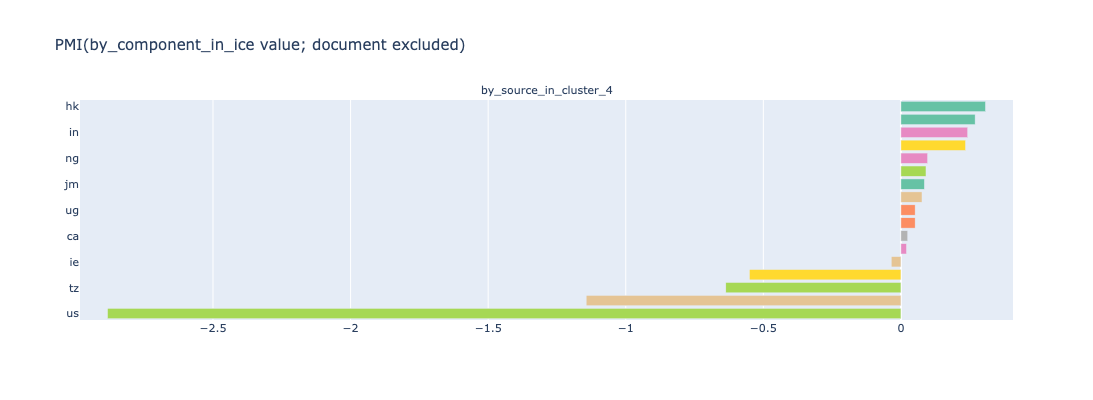

In [120]:
# for key, data in pmi_data.items():
#     render_pmi_bar(key, data).show()
render_pmi_bar("by_component_in_ice")

## Data Volume

*Operationalized hypothesis*: Cluster 1 will retain the most data and LEU centrality/peripherality will trend with volume retention.

The results are **positive**: Cluster 1 indeed retains the most volume throughout the stages of filtering. Surprisingly, the delta between cluster volumes sharply declines after FineWeb quality filter is applied, which shows the strength of filters blindly predicated on document length or punctuation character ratios.

In [20]:
def render_volume_line(stratum_key, color_map=COLOR_MAP,height=600,width=400, font_size=11):
    df = series[stratum_key]
    fig = px.line(
        df, x="stage", y="included", color="value",
        color_discrete_map=color_map, markers=True,
        title=f"Absolute volume by stage: {stratum_key}",
    )
    fig.update_layout(width=width, height=height, yaxis_title="records_remaining", font=dict(size=font_size))
    # fig.update_xaxes(range=[0.9,5.1], dtick=1)
    return fig

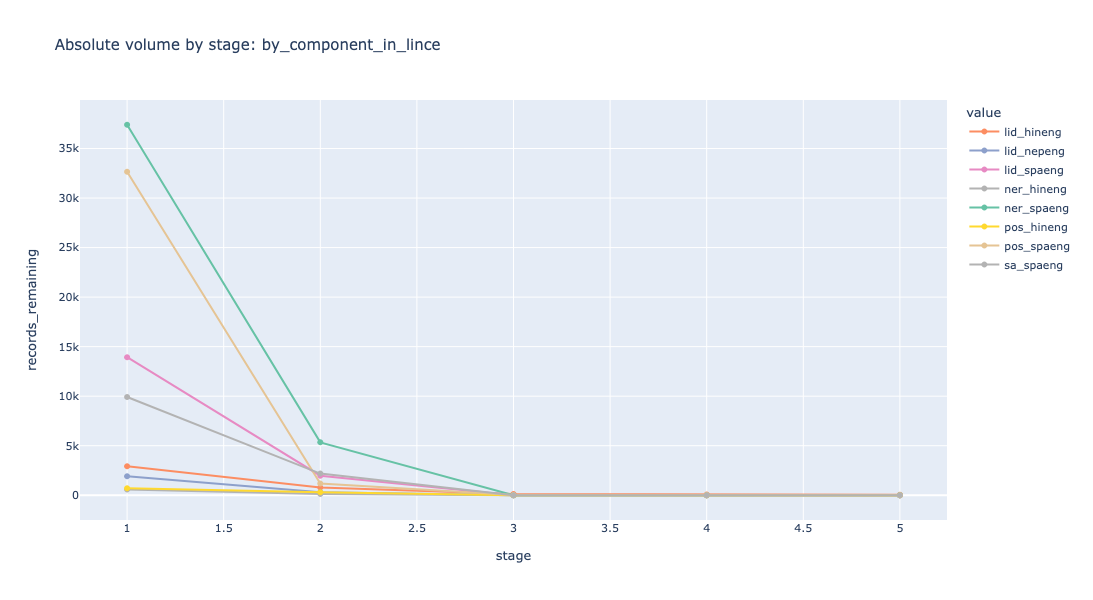

In [113]:
render_volume_line("by_component_in_lince")

## Render Sankey diagrams

In [65]:
def render_sankey(stratum_key, color_map=COLOR_MAP, width=1200, height=600, font_size=11):
    sd = sankeys[stratum_key]
    node_colors = [
        EXCLUDED_COLOR if label == "" else color_map.get(value, "#999999")
        for label, value in zip(sd["node"]["label"], sd["node"]["customdata"])
    ]
    fig = go.Figure(go.Sankey(node={**sd["node"], "color": node_colors}, link=sd["link"]))
    fig.update_layout(title=stratum_key, width=width, height=height, font=dict(size=font_size))
    return fig

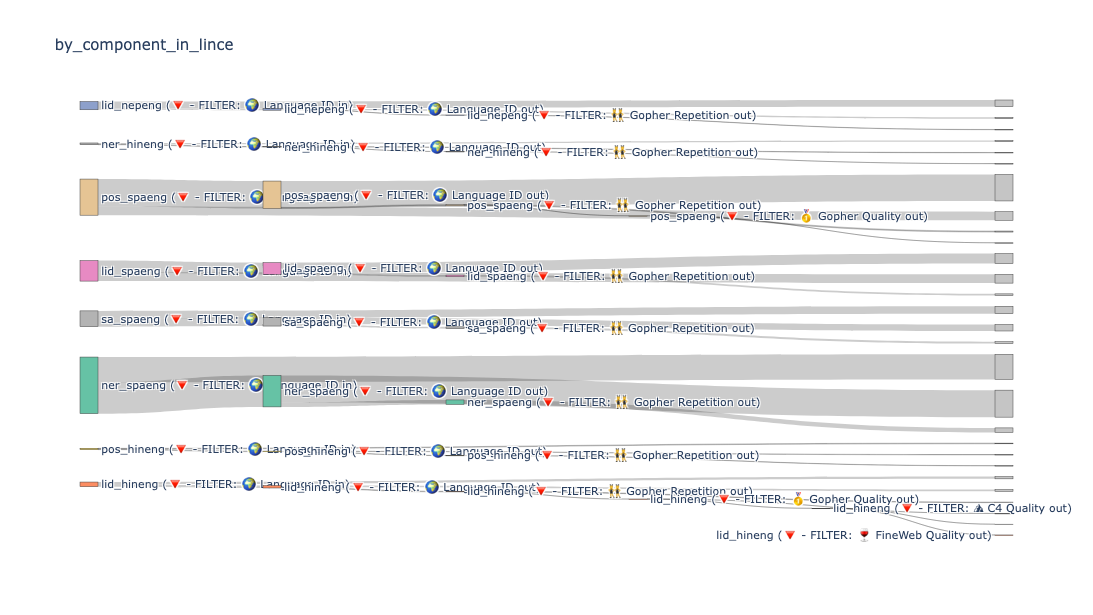

In [112]:
render_sankey("by_component_in_lince")

# Retention Rate (RR) and Log-Retention Penalty (LRP)
*Operationalized hypothesis*: Cluster 1 will have the highest retention rate at each stage of the pipeline. 

The results are **negative**: all clusters except for code-switching share nearly identical relative retention rates. There are more interesting results dealing with specifics of data provenance: source corpus, 

## Line Charts

In [72]:
def render_retention_line(stratum_key, color_map=COLOR_MAP,height=600,width=400, font_size=11):
    df = series[stratum_key]
    fig = px.line(
        df, x="stage", y="retention", color="value",
        color_discrete_map=color_map, markers=True,
        title=f"Retention by stage: {stratum_key}"
    )
    fig.update_layout(width=width, height=height, font=dict(size=font_size))
    fig.update_xaxes(range=[0.9,5.1], dtick=1)
    return fig

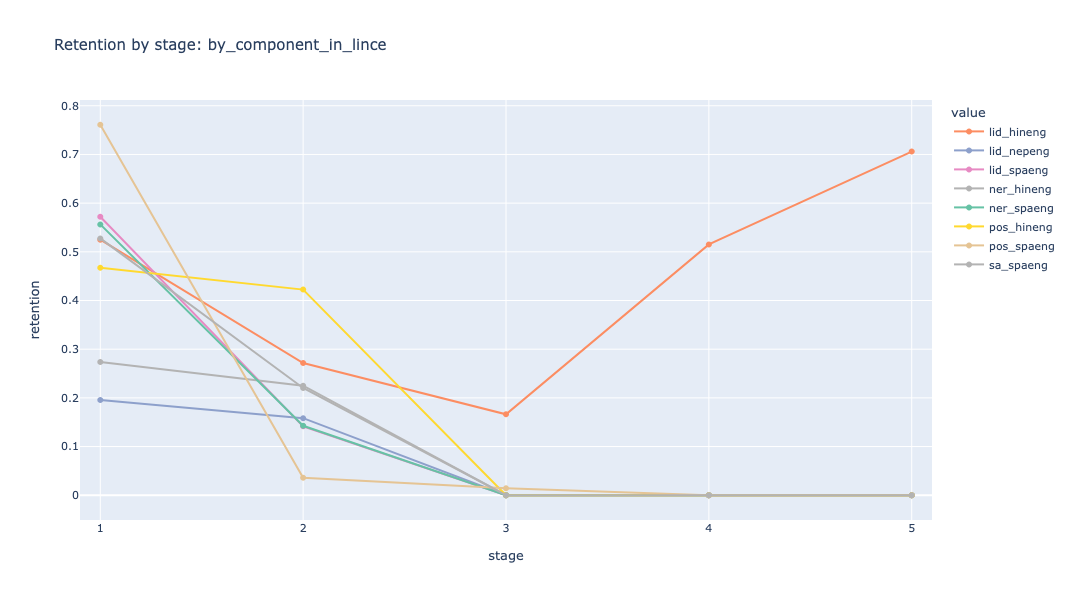

In [111]:
render_retention_line("by_component_in_lince", width=800)

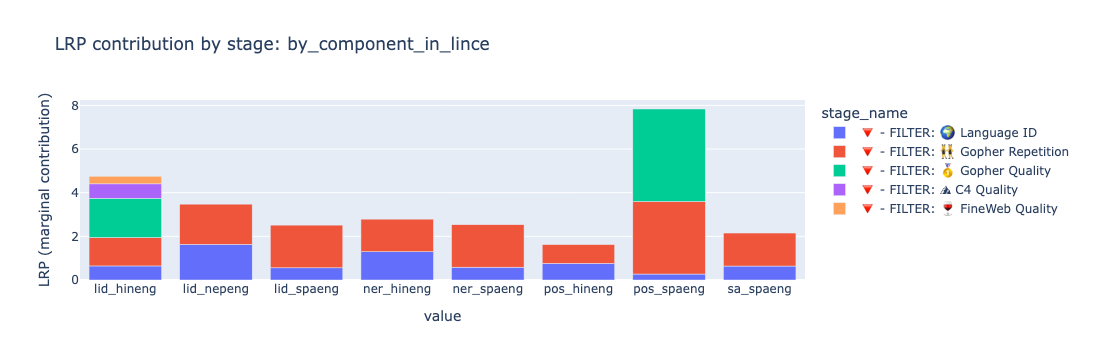

In [110]:
def render_lrp_contribution(stratum_key):
    df = series[stratum_key]
    fig = px.bar(
        df, x="value", y="lrp", color="stage_name",
        title=f"LRP contribution by stage: {stratum_key}",
        labels={"lrp": "LRP (marginal contribution)"}
    )
    return fig

render_lrp_contribution("by_component_in_lince")

## Waterfall Chart


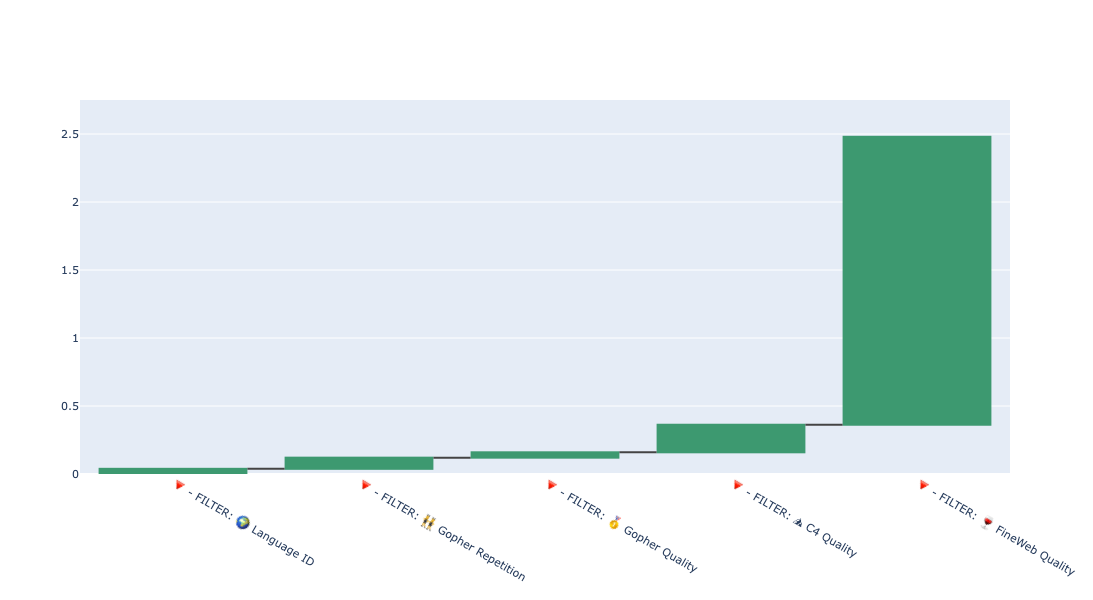

In [80]:
def render_lrp_contribution(stratum_key, color_map=COLOR_MAP, width=600, height=400, font_size=11):
    df = series[stratum_key]
    fig = go.Figure(go.Waterfall(
        orientation="v",
        x=df.stage_name,
        y=df.lrp    
    ))
    fig.update_yaxes(dtick=0.5, range=[0,2.75])
    fig.update_layout(width=width, height=height, font=dict(size=font_size))
    return fig

render_lrp_contribution("retention_overall", height=600)

In [79]:
series.keys()

dict_keys(['cluster', 'cluster_component', 'cluster_genre', 'cluster_in_glowbe', 'cluster_in_ice', 'cluster_source', 'component_genre', 'component_in_glowbe', 'component_in_ice', 'component_in_lince', 'genre_in_glowbe', 'genre_in_ice', 'source', 'source_in_cluster_1', 'source_in_cluster_2', 'source_in_cluster_3', 'source_in_cluster_4', 'retention_overall'])

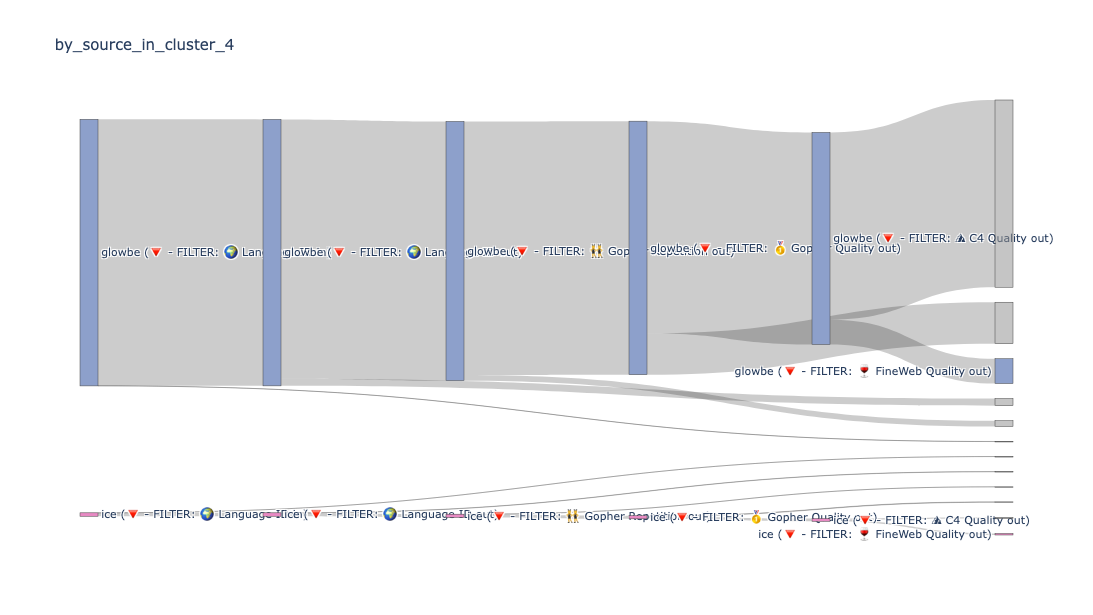

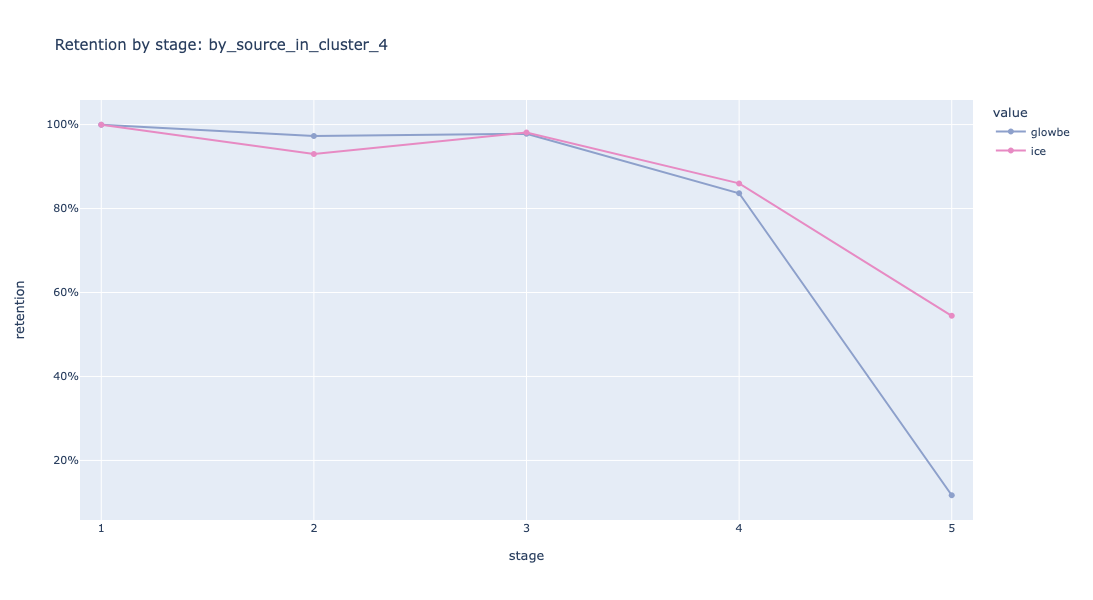

In [120]:
stratum = "by_source_in_cluster_4"

render_sankey(stratum).show()
render_retention_line(stratum).show()
# render_lrp_contribution(stratum).show()